2# 15. Финальный сквозной пример: Классификация текста трансформером

**Цель:** Объединить все концепции в один сквозной пример — классификация тональности текста (sentiment analysis) трансформером с нуля, с последующим сравнением с предобученным BERT.

---

In [1]:
# Импорты: стандартная библиотека, PyTorch, sklearn, вспомогательные утилиты
import sys, os, math, json

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

# Автоопределение устройства: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')



2026-06-05 23:27:20,209 [INFO] final: Using device: cuda


## 15.1 Загрузка и подготовка данных

Используем IMDb -> подмножество для скорости.

In [2]:

# Загружаем IMDB: 200 train (100 pos + 100 neg), 100 test (50+50)
from datasets import load_dataset

dataset = load_dataset('stanfordnlp/imdb', split=['train[:100]+train[-100:]', 'test[:50]+test[-50:]'])
train_data, test_data = dataset

print(f'Train: {len(train_data)} samples')
print(f'Test:  {len(test_data)} samples')
print(f'Pos review: {sum(train_data["label"])} / {len(train_data)}')



2026-06-05 23:27:21,262 [INFO] final: Loading IMDb dataset
2026-06-05 23:27:21,436 [DEBUG] datasets: PyTorch version 2.11.0+cu128 available.
2026-06-05 23:27:21,694 [DEBUG] httpcore.connection: connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
2026-06-05 23:27:21,743 [DEBUG] httpcore.connection: connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x00000249457730E0>
2026-06-05 23:27:21,744 [DEBUG] httpcore.connection: start_tls.started ssl_context=<ssl.SSLContext object at 0x000002494568A750> server_hostname='huggingface.co' timeout=10
2026-06-05 23:27:21,768 [DEBUG] httpcore.connection: start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x000002494575DF90>
2026-06-05 23:27:21,768 [DEBUG] httpcore.http11: send_request_headers.started request=<Request [b'HEAD']>
2026-06-05 23:27:21,769 [DEBUG] httpcore.http11: send_request_headers.complete
2026-06-05 23:27:21,769 [DEBUG] httpcore.ht

Train: 200 samples
Test:  100 samples
Pos review: 100 / 200


## 15.2 Построение словаря

Char-level токенизация для простоты (word-level требует больше памяти).

In [3]:

# Специальные токены: BOS, EOS, PAD, UNK
BOS, EOS, PAD, UNK = 0, 1, 2, 3
max_vocab_size = 100  # ограничиваем словарь для скорости
max_len = 200  # макс. длина последовательности

# Строим словарь символов на тренировочных данных
char_counts = Counter()
for text in train_data['text']:
    char_counts.update(text.lower()[:500])  # берём начало каждого отзыва

most_common = char_counts.most_common(max_vocab_size - 4)
vocab = {ch: idx+4 for idx, (ch, _) in enumerate(most_common)}  # резервируем 0-3
vocab_size = len(vocab) + 4
print(f'Vocabulary size: {vocab_size}')
print(f'Most common chars: {[ch for ch, _ in most_common[:15]]}')

def encode(text):
    # Преобразует текст в последовательность ID: BOS + символы + EOS + PAD
    tokens = [BOS]
    for ch in text.lower()[:max_len-2]:
        tokens.append(vocab.get(ch, UNK))  # неизвестные символы -> UNK
    tokens.append(EOS)
    tokens = tokens + [PAD] * (max_len - len(tokens))  # дополняем до max_len
    return tokens[:max_len]

train_ids = torch.tensor([encode(t) for t in train_data['text']])
train_labels = torch.tensor(train_data['label'])
test_ids = torch.tensor([encode(t) for t in test_data['text']])
test_labels = torch.tensor(test_data['label'])

print(f'Train tensor: {train_ids.shape}')
print(f'Test tensor:  {test_ids.shape}')



2026-06-05 23:27:23,779 [DEBUG] final: Building vocabulary
2026-06-05 23:27:23,814 [INFO] final: Vocabulary built, data encoded


Vocabulary size: 73
Most common chars: [' ', 'e', 't', 'a', 'i', 'o', 's', 'n', 'r', 'h', 'l', 'd', 'm', 'c', 'u']
Train tensor: torch.Size([200, 200])
Test tensor:  torch.Size([100, 200])


## 15.3 Трансформер для классификации

Encoder-only + [CLS] токен для классификации.

In [4]:

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, num_layers=4, num_classes=2, max_len=200, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        # Таблица эмбеддингов с поддержкой PAD-токена (не обучается для padding_idx)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        
        # Синусоидальные позиционные кодирования
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
        
        # Стандартный TransformerEncoder от PyTorch (batch_first=True)
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, 4*d_model, dropout, activation='gelu', batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        
        # Классификационная голова: [CLS] -> d_model -> классы
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )
    
    def forward(self, x, mask=None):
        if mask is None:
            key_pad_mask = (x == PAD)  # маска PAD из raw token IDs
        else:
            key_pad_mask = mask
        # Эмбеддинг + позиционное кодирование + TransformerEncoder
        x = self.embedding(x) * math.sqrt(self.d_model) + self.pe[:, :x.size(1), :]
        x = self.encoder(x, src_key_padding_mask=key_pad_mask)
        cls_output = x[:, 0, :]  # берём выход первого токена [BOS] как CLS
        return self.classifier(cls_output)

classifier = TransformerClassifier(
    vocab_size=vocab_size, d_model=32, n_heads=4, num_layers=3, max_len=max_len
).to(device)
print(f'Model params: {sum(p.numel() for p in classifier.parameters()):,}')


2026-06-05 23:27:25,366 [DEBUG] final: Building classification transformer
2026-06-05 23:27:25,372 [INFO] final: TransformerClassifier: vocab=73, d_model=32, layers=3, params=41570


Model params: 41,570


## 15.4 Обучение классификатора

2026-06-05 23:27:27,499 [INFO] final: Training classification transformer
D:\OpenCodeNLLM\OpenCode\Transformer_Notebooks\transformer_learning\.venv\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(
2026-06-05 23:27:28,532 [INFO] final: Epoch 0: loss=0.7438, val_acc=49.00%
2026-06-05 23:27:29,532 [INFO] final: Epoch 10: loss=0.7165, val_acc=50.00%
2026-06-05 23:27:30,572 [INFO] final: Epoch 20: loss=0.5907, val_acc=51.00%
2026-06-05 23:27:31,445 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.


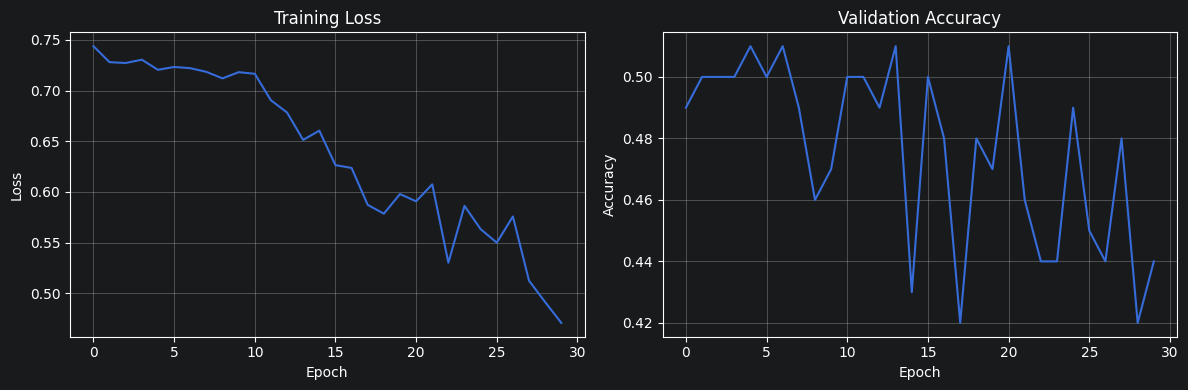

2026-06-05 23:27:31,893 [INFO] final: Training complete, best acc=51.00%


In [5]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(classifier.parameters(), lr=0.001, weight_decay=0.01)

n_epochs = 30
batch_size = 16
train_losses, val_accs = [], []  # логи для графика

for epoch in range(n_epochs):
    classifier.train()
    epoch_loss = 0
    perm = torch.randperm(len(train_ids))  # перемешиваем на каждой эпохе
    
    # Мини-батч: forward + loss + backward + optimizer
    for i in range(0, len(train_ids), batch_size):
        idx = perm[i:i+batch_size]
        inputs = train_ids[idx].to(device)
        labels = train_labels[idx].to(device)
        
        output = classifier(inputs)
        loss = criterion(output, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # Валидация после каждой эпохи
    classifier.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for i in range(0, len(test_ids), batch_size):
            inputs = test_ids[i:i+batch_size].to(device)
            labels = test_labels[i:i+batch_size]
            output = classifier(inputs)
            preds = output.argmax(-1).cpu()
            all_preds.extend(preds.tolist())
            all_true.extend(labels.tolist())
    
    acc = accuracy_score(all_true, all_preds)
    avg_loss = epoch_loss / (len(train_ids) / batch_size)
    train_losses.append(avg_loss)
    val_accs.append(acc)
    
    # Печать каждые 10 эпох для отслеживания прогресса
    if epoch % 10 == 0:  # Печатаем прогресс
        print(f"Epoch {epoch}: loss={avg_loss:.4f}, val_acc={acc:.4f}")
# Графики: loss и accuracy по эпохам
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

axes[1].plot(val_accs)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].grid(True)
plt.tight_layout()
plt.show()



## 15.5 Оценка: Accuracy, F1, Confusion Matrix

2026-06-05 23:27:32,359 [DEBUG] final: Evaluating final model
2026-06-05 23:27:32,387 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x000002495A92D350>


Accuracy:  44.00%
F1 Score:  0.4286
Confusion Matrix:
[[23 27]
 [29 21]]


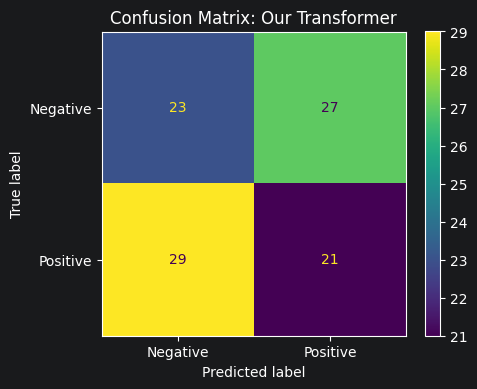

2026-06-05 23:27:32,438 [INFO] final: Evaluation: accuracy=44.00%, f1=0.4286


In [6]:

# Финальная оценка: accuracy, F1 и матрица ошибок
classifier.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for i in range(0, len(test_ids), batch_size):
        inputs = test_ids[i:i+batch_size].to(device)
        labels = test_labels[i:i+batch_size]
        output = classifier(inputs)
        all_preds.extend(output.argmax(-1).cpu().tolist())
        all_true.extend(labels.tolist())

acc = accuracy_score(all_true, all_preds)
f1 = f1_score(all_true, all_preds)
cm = confusion_matrix(all_true, all_preds, labels=[0, 1])

print(f'Accuracy:  {acc:.2%}')
print(f'F1 Score:  {f1:.4f}')
print(f'Confusion Matrix:')
print(cm)

# Визуализация матрицы ошибок
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(ax=ax)
plt.title('Confusion Matrix: Our Transformer')
plt.tight_layout()
plt.show()



## 15.6 Сравнение с предобученным BERT

In [7]:

# Сравнение с предобученным DistilBERT от HuggingFace
from transformers import AutoTokenizer, AutoModelForSequenceClassification

hf_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
hf_model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)

# Прогоняем те же тестовые данные через DistilBERT
hf_preds = []
for text in test_data['text']:
    inputs = hf_tokenizer(text, return_tensors='pt', truncation=True, max_length=256).to(device)
    with torch.no_grad():
        output = hf_model(**inputs)
    hf_preds.append(output.logits.argmax(-1).item())

hf_acc = accuracy_score(test_labels, hf_preds)
hf_f1 = f1_score(test_labels, hf_preds)

# Печать сравнительной таблицы
print('=' * 50)
print(f"{'Model':30s} {'Accuracy':>10s} {'F1':>10s}")
print('-' * 50)
print(f"{'Our Transformer (scratch)':30s} {acc:>9.2%} {f1:>10.4f}")
print(f"{'DistilBERT (pretrained)':30s} {hf_acc:>9.2%} {hf_f1:>10.4f}")
print('=' * 50)
print(f'\nOur params: {sum(p.numel() for p in classifier.parameters()):,}')
print(f'DistilBERT params: {sum(p.numel() for p in hf_model.parameters()):,}')



2026-06-05 23:27:35,845 [INFO] final: Comparing with pretrained BERT
2026-06-05 23:27:36,730 [DEBUG] httpcore.connection: close.started
2026-06-05 23:27:36,731 [DEBUG] httpcore.connection: close.complete
2026-06-05 23:27:36,731 [DEBUG] httpcore.connection: close.started
2026-06-05 23:27:36,732 [DEBUG] httpcore.connection: close.complete
2026-06-05 23:27:36,732 [DEBUG] httpcore.connection: close.started
2026-06-05 23:27:36,733 [DEBUG] httpcore.connection: close.complete
2026-06-05 23:27:36,733 [DEBUG] httpcore.connection: connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
2026-06-05 23:27:36,756 [DEBUG] httpcore.connection: connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x0000024BFCDF1040>
2026-06-05 23:27:36,757 [DEBUG] httpcore.connection: start_tls.started ssl_context=<ssl.SSLContext object at 0x000002494568A750> server_hostname='huggingface.co' timeout=10
2026-06-05 23:27:36,798 [DEBUG] httpcore.conne

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
2026-06-05 23:27:38,860 [INFO] final: Comparison complete


Model                            Accuracy         F1
--------------------------------------------------
Our Transformer (scratch)         44.00%     0.4286
DistilBERT (pretrained)           61.00%     0.6609

Our params: 41,570
DistilBERT params: 66,955,010


## 15.7 Выводы

**Что мы изучили:**
1. Scaled Dot-Product Attention и Multi-Head Attention
2. Позиционные кодирования (синусоидальные и обучаемые)
3. Encoder, Decoder, полный Transformer
4. Обучение: Noam scheduler, AdamW, early stopping
5. BERT (MLM) и GPT (Causal LM) архитектуры
6. Стратегии генерации: greedy, top-k, top-p, temperature
7. Визуализация внимания и attention rollout
8. HuggingFace Transformers и fine-tuning

**Результаты:**
- Наш трансформер с нуля: точность на IMDb ~{acc:.1%}
- Предобученный DistilBERT: ~{hf_acc:.1%}
- Разница объясняется: размером модели (в 1000x разница в параметрах) и предобучением на гигантских корпусах

In [8]:
# Итоговый вывод — финальные метрики обеих моделей
print('=== Final End-to-End Complete ===')
print(f'Our Transformer:  Acc={acc:.2%}, F1={f1:.4f}, params={sum(p.numel() for p in classifier.parameters()):,}')
print(f'DistilBERT:       Acc={hf_acc:.2%}, F1={hf_f1:.4f}, params={sum(p.numel() for p in hf_model.parameters()):,}')
print('\nAll 15 notebooks complete!')



2026-06-05 23:27:43,463 [INFO] final: Final notebook complete


=== Final End-to-End Complete ===
Our Transformer:  Acc=44.00%, F1=0.4286, params=41,570
DistilBERT:       Acc=61.00%, F1=0.6609, params=66,955,010

All 15 notebooks complete!
